# Generación y selección de características

En esta etapa se transforman los archivos de audio en representaciones numéricas que puedan ser utilizadas por los modelos de clasificación. Como los algoritmos de aprendizaje automático no trabajan directamente con la señal cruda, es necesario extraer características que resuman información relevante del audio.

Para este proyecto se utilizarán dos enfoques:

- Un enfoque basado en características acústicas agregadas para el modelo **Random Forest**.
- Un enfoque basado en **espectrogramas Mel** como entrada para la **CNN**.


## 1. Librerías


In [1]:
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

plt.rcParams['figure.figsize'] = (10, 4)


## 2. Rutas del dataset

En este caso se usará la versión `for-norm`, separada en entrenamiento, validación y prueba.


In [4]:
TRAIN_REAL = 'archive (3)/for-norm/for-norm/training/real/*.wav'
TRAIN_FAKE = 'archive (3)/for-norm/for-norm/training/fake/*.wav'

VAL_REAL = 'archive (3)/for-norm/for-norm/validation/real/*.wav'
VAL_FAKE = 'archive (3)/for-norm/for-norm/validation/fake/*.wav'

TEST_REAL = 'archive (3)/for-norm/for-norm/testing/real/*.wav'
TEST_FAKE = 'archive (3)/for-norm/for-norm/testing/fake/*.wav'

train_real_files = glob(TRAIN_REAL)
train_fake_files = glob(TRAIN_FAKE)
val_real_files = glob(VAL_REAL)
val_fake_files = glob(VAL_FAKE)
test_real_files = glob(TEST_REAL)
test_fake_files = glob(TEST_FAKE)

print('Train real:', len(train_real_files))
print('Train fake:', len(train_fake_files))
print('Validation real:', len(val_real_files))
print('Validation fake:', len(val_fake_files))
print('Test real:', len(test_real_files))
print('Test fake:', len(test_fake_files))


Train real: 26941
Train fake: 26927
Validation real: 5400
Validation fake: 5398
Test real: 2264
Test fake: 2370


## 3. ¿Qué características se van a utilizar?

Para el modelo Random Forest se trabajará con características acústicas que resumen propiedades importantes de la señal:

- **MFCC**: describen el contenido espectral del audio en una escala similar a la percepción humana.
- **Zero Crossing Rate (ZCR)**: mide cuántas veces la señal cruza el cero y ayuda a describir su variabilidad.
- **Spectral Centroid**: indica dónde se concentra la energía del espectro.
- **RMS Energy**: representa la intensidad promedio de la señal.
- **Spectral Bandwidth**: describe la dispersión de la energía alrededor del centroide.
- **Spectral Rolloff**: muestra hasta qué frecuencia se acumula la mayor parte de la energía.

Para la CNN se utilizará el **espectrograma Mel**, ya que conserva la información tiempo-frecuencia y puede tratarse como una imagen.


## 4. Función para extraer características acústicas

La siguiente función calcula un conjunto de características por archivo y devuelve un diccionario listo para almacenarse en un DataFrame.


In [5]:
def extract_features(file_path, n_mfcc=13):
    audio, sr = librosa.load(file_path, sr=None)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    zcr = librosa.feature.zero_crossing_rate(audio)
    spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)
    rms = librosa.feature.rms(y=audio)

    features = {
        'duration': len(audio) / sr,
        'sample_rate': sr,
        'zcr_mean': float(np.mean(zcr)),
        'zcr_std': float(np.std(zcr)),
        'spectral_centroid_mean': float(np.mean(spectral_centroid)),
        'spectral_centroid_std': float(np.std(spectral_centroid)),
        'spectral_bandwidth_mean': float(np.mean(spectral_bandwidth)),
        'spectral_bandwidth_std': float(np.std(spectral_bandwidth)),
        'spectral_rolloff_mean': float(np.mean(spectral_rolloff)),
        'spectral_rolloff_std': float(np.std(spectral_rolloff)),
        'rms_mean': float(np.mean(rms)),
        'rms_std': float(np.std(rms)),
    }

    for i in range(n_mfcc):
        features[f'mfcc_{i+1}_mean'] = float(np.mean(mfcc[i]))
        features[f'mfcc_{i+1}_std'] = float(np.std(mfcc[i]))

    return features


## 5. Prueba con un archivo

Antes de procesar todo el conjunto, probamos la función con un solo audio.


In [6]:
sample_file = train_real_files[0] if train_real_files else None

if sample_file:
    sample_features = extract_features(sample_file)
    print('Cantidad de características extraídas:', len(sample_features))
    print(sample_features)
else:
    print('No se encontró un archivo de ejemplo.')


Cantidad de características extraídas: 38
{'duration': 2.501625, 'sample_rate': 16000, 'zcr_mean': 0.1374604430379747, 'zcr_std': 0.10771245212650095, 'spectral_centroid_mean': 1822.402563454483, 'spectral_centroid_std': 1013.998923883665, 'spectral_bandwidth_mean': 1500.0863476742352, 'spectral_bandwidth_std': 461.65008855071943, 'spectral_rolloff_mean': 3311.115506329114, 'spectral_rolloff_std': 1478.54386366884, 'rms_mean': 0.12617219984531403, 'rms_std': 0.06989842653274536, 'mfcc_1_mean': -210.42758178710938, 'mfcc_1_std': 93.1534652709961, 'mfcc_2_mean': 83.10088348388672, 'mfcc_2_std': 57.79098129272461, 'mfcc_3_mean': -13.509092330932617, 'mfcc_3_std': 41.297157287597656, 'mfcc_4_mean': 8.969432830810547, 'mfcc_4_std': 33.19512939453125, 'mfcc_5_mean': -22.99516487121582, 'mfcc_5_std': 30.555423736572266, 'mfcc_6_mean': -24.025053024291992, 'mfcc_6_std': 20.822893142700195, 'mfcc_7_mean': -36.12419509887695, 'mfcc_7_std': 17.65709686279297, 'mfcc_8_mean': -21.663410186767578, '

## 6. Generación del conjunto de características

En esta parte se construye una tabla con los audios del conjunto de entrenamiento. 

In [7]:
def build_feature_table(real_files, fake_files, limit_per_class=None):
    rows = []

    if limit_per_class is not None:
        real_files = real_files[:limit_per_class]
        fake_files = fake_files[:limit_per_class]

    for f in real_files:
        try:
            features = extract_features(f)
            features['label'] = 0
            features['class_name'] = 'real'
            features['file_name'] = os.path.basename(f)
            rows.append(features)
        except Exception as e:
            print(f'Error en archivo real {f}: {e}')

    for f in fake_files:
        try:
            features = extract_features(f)
            features['label'] = 1
            features['class_name'] = 'fake'
            features['file_name'] = os.path.basename(f)
            rows.append(features)
        except Exception as e:
            print(f'Error en archivo fake {f}: {e}')

    return pd.DataFrame(rows)


In [13]:
# limit_per_class según capacidad de cómputo
df_train_features = build_feature_table(train_real_files, train_fake_files, limit_per_class=500)
df_train_features.head()


,duration,sample_rate,zcr_mean,zcr_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwidth_mean,spectral_bandwidth_std,spectral_rolloff_mean,spectral_rolloff_std,...,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,label,class_name,file_name
0,2.501625,16000,0.137460,0.107712,1822.402563,1013.998924,1500.086348,461.650089,3311.115506,1478.543864,...,11.559100,-13.836758,12.222466,-7.984338,11.914497,3.527972,9.191850,0,real,file1.wav_16k.wav_norm.wav_mono.wav_silence.wav
1,3.903625,16000,0.154065,0.142022,1768.520360,1094.012772,1465.244396,334.323075,3338.242828,1384.581857,...,11.825932,-8.748558,11.612570,-3.333731,7.162339,0.747620,8.394314,0,real,file10.wav_16k.wav_norm.wav_mono.wav_silence.wav
2,3.491062,16000,0.095206,0.108298,1446.031905,1158.978658,1533.366622,512.955487,2730.610795,2073.645401,...,9.080853,-5.557889,10.118581,-1.045880,11.342930,-8.296654,9.514001,0,real,file100.wav_16k.wav_norm.wav_mono.wav_silence.wav
3,9.532187,16000,0.188090,0.168110,2033.304687,1437.124038,1511.028950,553.590827,3504.194631,2048.101107,...,14.186908,-23.158998,12.469376,-6.387084,10.967032,-4.906898,9.316609,0,real,file1000.wav_16k.wav_norm.wav_mono.wav_silence...
4,4.185125,16000,0.193106,0.200250,2081.626495,1636.240108,1411.119670,539.384866,3395.873092,2131.512957,...,12.260043,-18.606728,13.310192,-13.368902,9.351854,0.640401,9.405801,0,real,file10000.wav_16k.wav_norm.wav_mono.wav_silenc...


## 7. Revisión inicial de la tabla de características


In [14]:
print('Dimensiones del DataFrame:', df_train_features.shape)
print('\nColumnas:')
print(df_train_features.columns.tolist())


Dimensiones del DataFrame: (1000, 41)

Columnas:
['duration', 'sample_rate', 'zcr_mean', 'zcr_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'rms_mean', 'rms_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'label', 'class_name', 'file_name']


In [15]:
df_train_features.groupby('class_name').mean(numeric_only=True).T.head(20)


class_name,fake,real
duration,1.660739,4.540805
sample_rate,16000.000000,16000.000000
zcr_mean,0.131521,0.147668
zcr_std,0.102386,0.126965
spectral_centroid_mean,1591.190117,1865.681709
spectral_centroid_std,940.366057,1134.549091
spectral_bandwidth_mean,1404.095998,1542.462810
spectral_bandwidth_std,414.727263,437.116665
spectral_rolloff_mean,2925.057979,3356.331259
spectral_rolloff_std,1530.776088,1675.104172


## 8. Visualización de algunas características

Se comparan distribuciones de algunas variables para ver si existe separación entre las clases.


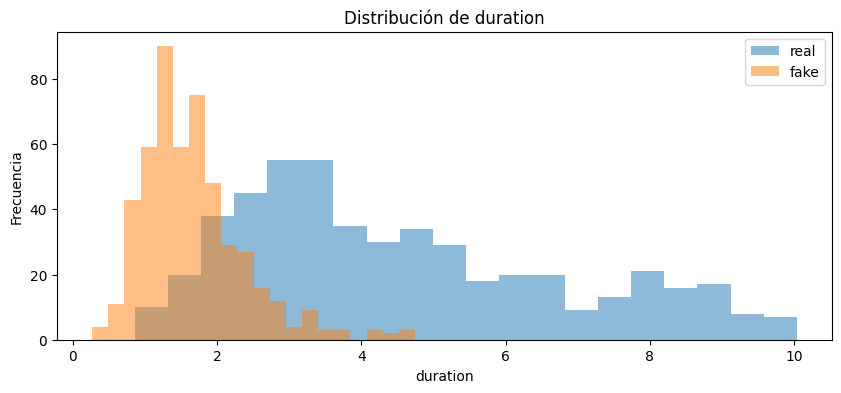

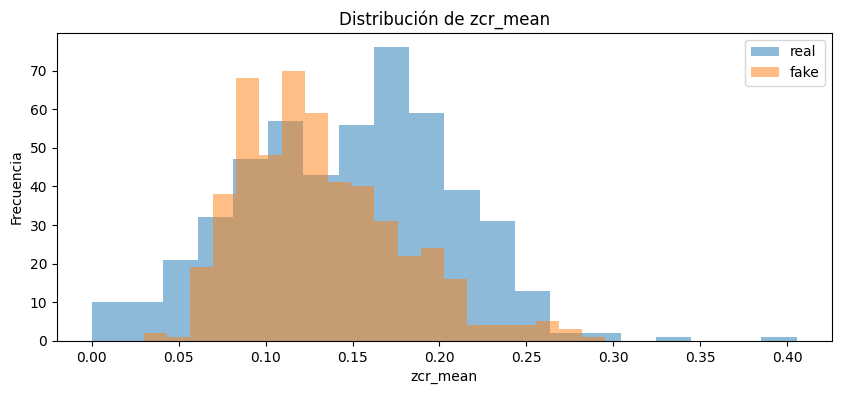

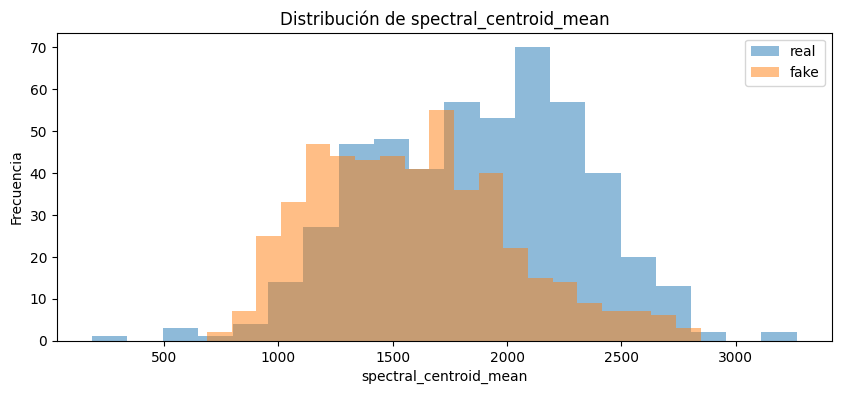

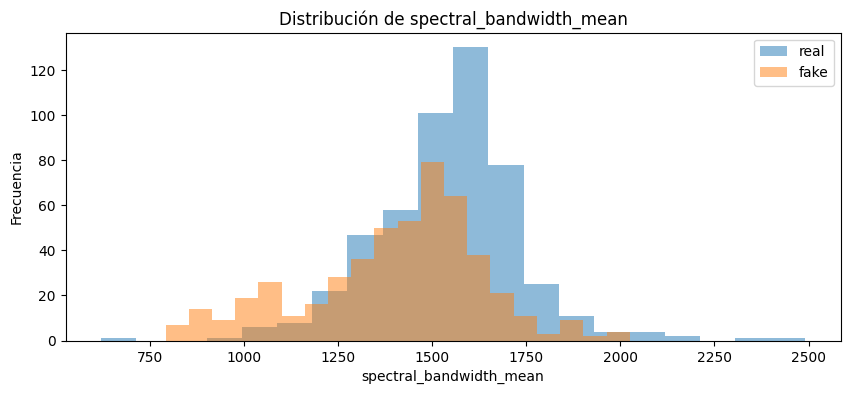

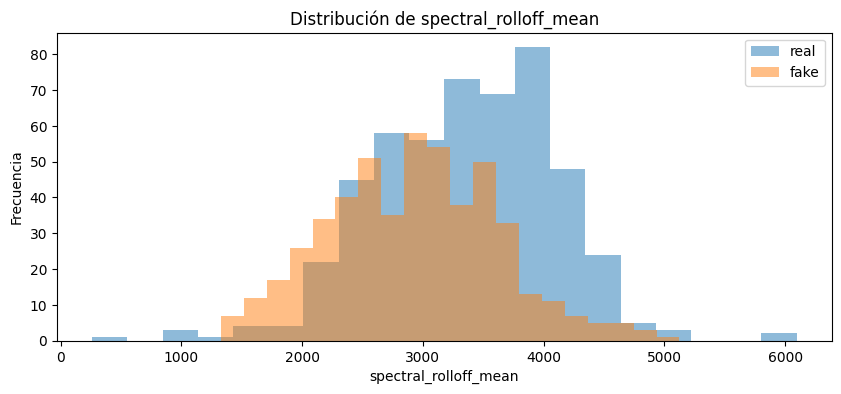

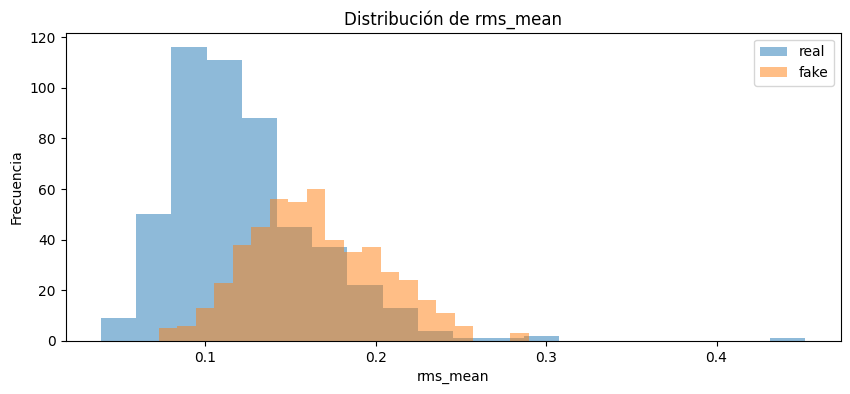

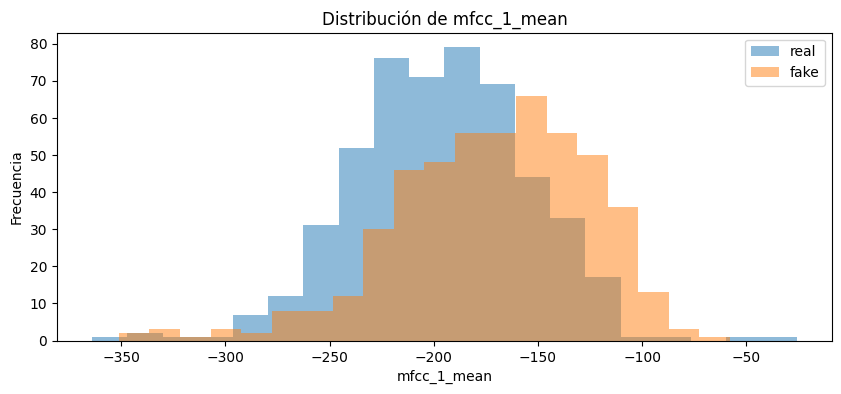

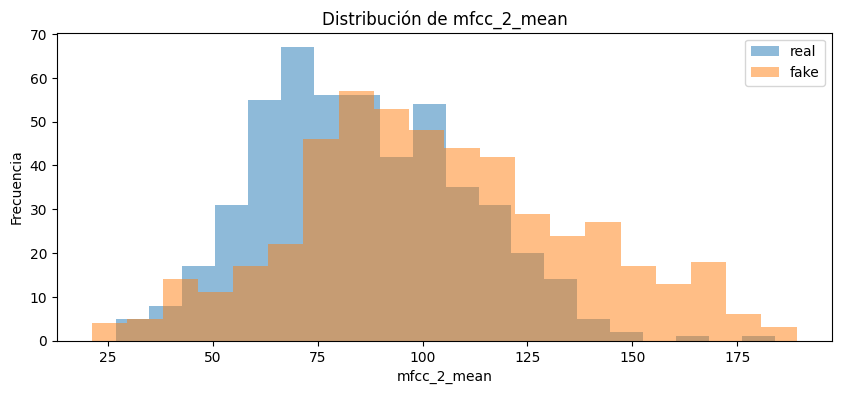

In [16]:
features_to_plot = [
    'duration',
    'zcr_mean',
    'spectral_centroid_mean',
    'spectral_bandwidth_mean',
    'spectral_rolloff_mean',
    'rms_mean',
    'mfcc_1_mean',
    'mfcc_2_mean'
]

for feature in features_to_plot:
    plt.figure()
    real_values = df_train_features[df_train_features['class_name'] == 'real'][feature]
    fake_values = df_train_features[df_train_features['class_name'] == 'fake'][feature]
    plt.hist(real_values, bins=20, alpha=0.5, label='real')
    plt.hist(fake_values, bins=20, alpha=0.5, label='fake')
    plt.title(f'Distribución de {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frecuencia')
    plt.legend()
    plt.show()


## 9. Selección de características para Random Forest

Para el modelo Random Forest se usarán únicamente columnas numéricas, excluyendo el nombre del archivo y las etiquetas de texto.


In [17]:
excluded_columns = ['label', 'class_name', 'file_name']
feature_columns = [col for col in df_train_features.columns if col not in excluded_columns]

X_train_rf = df_train_features[feature_columns]
y_train_rf = df_train_features['label']

print('Cantidad de características para Random Forest:', len(feature_columns))
print('Forma de X_train_rf:', X_train_rf.shape)
print('Forma de y_train_rf:', y_train_rf.shape)


Cantidad de características para Random Forest: 38
Forma de X_train_rf: (1000, 38)
Forma de y_train_rf: (1000,)


## 10. Generación de espectrograma Mel para la CNN

La CNN no se trabajará con las características agregadas, sino con una representación tiempo-frecuencia del audio.


In [18]:
def create_mel_spectrogram(file_path, n_mels=128, hop_length=512):
    audio, sr = librosa.load(file_path, sr=None)
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=n_mels,
        hop_length=hop_length
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db


Forma del espectrograma: (128, 39)


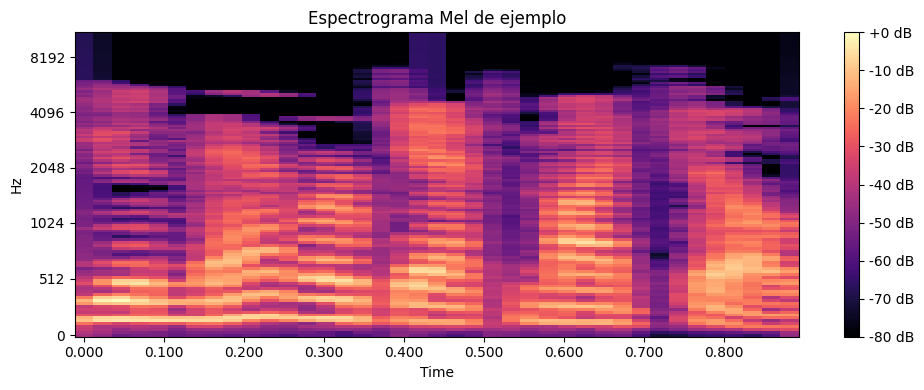

In [19]:
if train_fake_files:
    mel_example = create_mel_spectrogram(train_fake_files[0])
    print('Forma del espectrograma:', mel_example.shape)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_example, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Espectrograma Mel de ejemplo')
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró un archivo fake para generar el ejemplo.')


## 11. Comentarios sobre la selección final

Se procesaron los archivos de audio y se extrajeron características representativas de la señal, permitiendo obtener una estructura de datos organizada que puede utilizarse como entrada para los modelos de clasificación. Este proceso permite capturar información relevante del comportamiento de la señal de audio y facilita la comparación entre muestras de voz real y voz sintética.

Asimismo, se verificó la consistencia de las características generadas, asegurando que los datos puedan utilizarse correctamente en las etapas posteriores del proyecto. La generación de características constituye un paso fundamental, ya que permite representar la información del audio de manera numérica y estructurada.

Los resultados obtenidos en esta fase permiten continuar con el entrenamiento de modelos de Machine Learning y Deep Learning para evaluar su desempeño en la detección de voz sintética.